## Prognose der  Zigarettenpreis und der Zigarettenkonsum in Deutschland bis zum Jahr 2032?
Frage: Wie entwickeln sich der Zigarettenpreis und der Zigarettenkonsum in Deutschland bis zum Jahr 2032?
Ziel: Ziel dieser Analyse ist es, die Entwicklung des Zigarettenpreises und des Zigarettenkonsums in Deutschland zu untersuchen. Mithilfe einer Prognose sollen mögliche zukünftige Trends bis 2032 dargestellt werden.

In [1]:
import pandas as pd
import sys
from pathlib import Path

projekt_ordner = Path.cwd().parent  # sube a Informprojekt_SoSe2026
sys.path.append(str(projekt_ordner))

output_ordner = Path.cwd() / "grafiken"
output_ordner.mkdir(parents=True, exist_ok=True)

# Excel están en la misma carpeta que el notebook
preis_datei = Path.cwd() / "_durchschnittlicher-zigarettenpreis-in-deutschland.xlsx"
konsum_datei = Path.cwd() / "_pro-kopf-verbrauch-von-zigaretten-in-deutschland.xlsx"


In [2]:
def create_table(datei, spaltenname):
    df = pd.read_excel(
        datei,
        sheet_name="Daten",
        header=None
    )
    df = df[[1, 2]]
    df.columns = ["year", spaltenname]
    df = df.dropna()

    display(df.tail(10).style.hide(axis="index"))  # show preview
    return df                                       # return full df

In [3]:
preis_df = create_table(
    "_durchschnittlicher-zigarettenpreis-in-deutschland.xlsx",
    "price_cent"
)

konsum_df = create_table(
    "_pro-kopf-verbrauch-von-zigaretten-in-deutschland.xlsx",
    "consumption_per_capita"
)

year,price_cent
2016,27.360000
2017,28.170000
2018,29.120000
2019,30.130000
2020,30.880000
2021,31.650000
2022,33.270000
2023,35.180000
2024,36.650000
2025,38.100000


year,consumption_per_capita
2016,911.000000
2017,917.000000
2018,897.000000
2019,898.000000
2020,888.000000
2021,863.000000
2022,785.000000
2023,769.000000
2024,793.000000
2025,795.000000


In [4]:
#def um die Schwankungen zu sehen
def calculate_change(df, spaltenname):

    erste_wert = df[spaltenname].iloc[0]

    letzte_wert = df[spaltenname].iloc[-1]

    veraenderung = (
        (letzte_wert / erste_wert) - 1
    ) * 100

    if veraenderung > 0:

        print(
            f"{spaltenname} ist um "
            f"{veraenderung:.2f}% gestiegen."
        )

    else:

        print(
            f"{spaltenname} ist um "
            f"{abs(veraenderung):.2f}% gesunken."
        )

In [5]:
preis_df["year"] = preis_df["year"].astype(int)
konsum_df["year"] = konsum_df["year"].astype(int)

preis_df_filtered = preis_df[preis_df["year"] >= 2016]
konsum_df_filtered = konsum_df[konsum_df["year"] >= 2016]

------------------------PROGNOSE-----------------

In [6]:
# Prognose bis 2032

future_years = [
    2027,
    2028,
    2029,
    2030,
    2031,
    2032
]

last_preis = preis_df["price_cent"].iloc[-1]

last_konsum = konsum_df[
    "consumption_per_capita"
].iloc[-1]

future_preise = []

future_konsum = []

for year in future_years:

    # Preis steigt
    last_preis *= 1.03

    # Konsum sinkt
    last_konsum *= 0.98

    future_preise.append(last_preis)

    future_konsum.append(last_konsum)

In [7]:
prognose_df = pd.DataFrame({
    "year": future_years,
    "preis_prognose": future_preise,
    "konsum_prognose": future_konsum
})

prognose_df

,year,preis_prognose,konsum_prognose
0,2027,39.243000,779.100000
1,2028,40.420290,763.518000
2,2029,41.632899,748.247640
3,2030,42.881886,733.282687
4,2031,44.168342,718.617033
5,2032,45.493392,704.244693


In [ ]:
from src.plot_utils import plot_zwei_achsencolors


In [ ]:
from src.plot_utils import plot_zwei_achsencolors


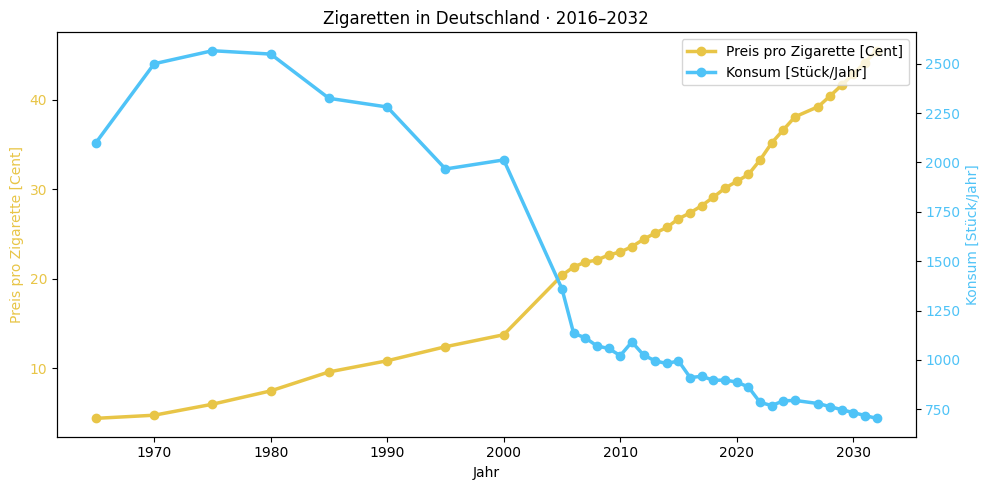

NameError: name 'plt' is not defined

In [9]:
# Datos históricos + prognose en un solo df
alle_jahre  = list(preis_df["year"]) + future_years
alle_preise = list(preis_df["price_cent"]) + future_preise
alle_konsum = list(konsum_df["consumption_per_capita"]) + future_konsum

df_grafik = pd.DataFrame({
    "year":                   alle_jahre,
    "price_cent":             alle_preise,
    "consumption_per_capita": alle_konsum
})

plot_zwei_achsencolors(
    df_grafik,
    "year",
    "price_cent",
    "consumption_per_capita",
    "Zigaretten in Deutschland · 2016–2032",
    "Jahr",
    "Preis pro Zigarette [Cent]",
    "Konsum [Stück/Jahr]",
    output_ordner / "prognose_kombiniert.png"
)
plt.style.use("dark_background")

## Fazit: 
Die Analyse zeigt einen deutlichen Zusammenhang zwischen dem Zigarettenpreis und dem Zigarettenkonsum in Deutschland. Während der Preis über die Jahre kontinuierlich gestiegen ist, ist der Konsum deutlich zurückgegangen.
Die Prognose bis 2032 deutet darauf hin, dass sich dieser Trend fortsetzen könnte. Steigende Preise könnten dazu beitragen, den Zigarettenkonsum weiter zu reduzieren. Insgesamt zeigt die Analyse eine negative Beziehung zwischen Preis und Konsum.